# Spotify Tracks EDA
Goal: verify the data is clean and ready for the restaurant song recommendation engine.

Checks:
1. Shape & dtypes
2. Missing values
3. Duplicates
4. Audio feature ranges (Spotify spec)
5. Outliers & anomalies
6. Distributions
7. Categorical sanity checks
8. Year / release_date consistency
9. Cleaning summary

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

FILEPATH = r"C:\Users\ryanm\Documents\coding_projects\restaurant_recommendation\data\raw\tracks_features.csv"

df = pd.read_csv(FILEPATH)
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

## 1. Shape & Data Types

In [2]:
print(df.dtypes)
df.head(3)

id                   object
name                 object
album                object
album_id             object
artists              object
artist_ids           object
track_number          int64
disc_number           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
duration_ms           int64
time_signature      float64
year                  int64
release_date         object
dtype: object


,id,name,album,album_id,artists,artist_ids,track_number,disc_number,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,year,release_date
0,7lmeHLHBe4nmXzuXc0HDjk,Testify,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],1,1,False,0.470,0.978,7,-5.399,1,0.0727,0.0261,0.000011,0.356,0.503,117.906,210133,4.0,1999,1999-11-02
1,1wsRitfRRtWyEapl0q22o8,Guerrilla Radio,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],2,1,True,0.599,0.957,11,-5.764,1,0.1880,0.0129,0.000071,0.155,0.489,103.680,206200,4.0,1999,1999-11-02
2,1hR0fIFK2qRG3f3RF70pb7,Calm Like a Bomb,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],3,1,False,0.315,0.970,7,-5.424,1,0.4830,0.0234,0.000002,0.122,0.370,149.749,298893,4.0,1999,1999-11-02


## 2. Missing Values

In [3]:
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(4)

missing = pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct})
missing = missing[missing['null_count'] > 0]

if missing.empty:
    print("No missing values.")
else:
    print(f"{missing['null_count'].sum()} total nulls across {len(missing)} columns:")
    display(missing)

14 total nulls across 2 columns:


,null_count,null_pct
name,3,0.0002
album,11,0.0009


In [4]:
# Show the null rows
null_rows = df[df.isnull().any(axis=1)]
print(f"Rows with at least one null: {len(null_rows)}")
display(null_rows)

Rows with at least one null: 13


,id,name,album,album_id,artists,artist_ids,track_number,disc_number,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,year,release_date
387109,7r3l7R0Ob1XcRk6woND7It,NaN,Distort Neural Unit,490Mh7XZ2RMAdUFLyIeIjk,['K-Bereit'],['0AlkK3VjSA5wwDVO382B0y'],1,1,False,0.581,0.704,10,-11.316,0,0.0353,0.00114,0.412000,0.3620,0.117,120.025,282840,4.0,2009,2009-01-01
869543,0Ii9PaRffU4y8Tg1qMfV92,NaN,Hard to Hit,15nI3HMMle3zSsrVNUjdRM,"['Big Mike', 'Yukmouth', ""Tre'mendous""]","['2NeBwEmM7I71IsGl1y6FG0', '0ndMofuAPmTktjONZv...",19,1,True,0.890,0.641,1,-10.379,1,0.2590,0.00243,0.000002,0.0849,0.359,100.045,230293,4.0,1999,1999-05-25
1018344,5dQ6x9vR5gaxIQFAqFTGhN,NaN,NaN,0FuahJaNlb2xX87G54NSLj,['Gupi'],['3YOvdmjSEwOqRAJ0ttfwCx'],1,1,False,0.630,0.917,0,-5.143,1,0.0637,0.09820,0.678000,0.0964,0.826,140.011,246337,4.0,2020,2020-02-25
1018345,44DdlS9pHh9FPnd8Kl6P6u,Modest,NaN,0FuahJaNlb2xX87G54NSLj,['Gupi'],['3YOvdmjSEwOqRAJ0ttfwCx'],2,1,False,0.729,0.668,0,-5.135,1,0.0503,0.04300,0.000013,0.1230,0.947,117.033,182126,4.0,2020,2020-02-25
1018346,0e1GhxlLVzjKC2OMJR4xgO,Paradise,NaN,0FuahJaNlb2xX87G54NSLj,['Gupi'],['3YOvdmjSEwOqRAJ0ttfwCx'],3,1,False,0.640,0.972,1,-5.048,0,0.1500,0.00608,0.607000,0.1100,0.841,170.010,197836,4.0,2020,2020-02-25
1018347,4ZF0yCc8yqid53tv9pCgm5,Spencer Adventure 2,NaN,0FuahJaNlb2xX87G54NSLj,['Gupi'],['3YOvdmjSEwOqRAJ0ttfwCx'],4,1,False,0.565,0.746,1,-5.810,0,0.2530,0.06620,0.762000,0.1020,0.689,149.943,171165,4.0,2020,2020-02-25
1018348,64mmh0EoR0n5ROKQZZB5hT,Plymouth Simulation,NaN,0FuahJaNlb2xX87G54NSLj,['Gupi'],['3YOvdmjSEwOqRAJ0ttfwCx'],5,1,False,0.703,0.752,11,-5.857,0,0.2550,0.03360,0.579000,0.0620,0.901,170.055,186272,4.0,2020,2020-02-25
1018349,51IvHGlNqG8jIEEDiJuJyZ,Driving Directly Into A Concrete Wall,NaN,0FuahJaNlb2xX87G54NSLj,['Gupi'],['3YOvdmjSEwOqRAJ0ttfwCx'],6,1,False,0.740,0.897,1,-4.896,1,0.1620,0.22100,0.121000,0.3600,0.935,139.977,202566,4.0,2020,2020-02-25
1018350,52rpjws4EuaZcsKcNN9m25,Regression,NaN,0FuahJaNlb2xX87G54NSLj,['Gupi'],['3YOvdmjSEwOqRAJ0ttfwCx'],7,1,False,0.680,0.907,1,-4.675,1,0.0909,0.00110,0.831000,0.3330,0.861,142.959,188156,4.0,2020,2020-02-25
1018351,6pe1T2thmWds9hPq67Xv74,Thos Moser,NaN,0FuahJaNlb2xX87G54NSLj,"['Gupi', 'Fraxiom', 'food house']","['3YOvdmjSEwOqRAJ0ttfwCx', '04Y5zXsFqYRzDr6tMX...",8,1,True,0.766,0.637,3,-4.785,1,0.2090,0.03050,0.000222,0.0836,0.619,134.981,263364,4.0,2020,2020-02-25


## 3. Duplicates

In [5]:
# Full row duplicates
full_dups = df.duplicated().sum()
print(f"Full duplicate rows: {full_dups}")

# Duplicate track IDs
id_dups = df.duplicated(subset='id').sum()
print(f"Duplicate track IDs: {id_dups}")

# Duplicate name + artists combos (same song different versions expected, just FYI)
name_artist_dups = df.duplicated(subset=['name', 'artists']).sum()
print(f"Duplicate name+artist combos: {name_artist_dups} (remasters/versions expected)")

Full duplicate rows: 0
Duplicate track IDs: 0
Duplicate name+artist combos: 62469 (remasters/versions expected)


## 4. Audio Feature Ranges (Spotify Spec)
Expected ranges per Spotify API:
- danceability, energy, speechiness, acousticness, instrumentalness, liveness, valence: 0.0–1.0
- key: 0–11 (or -1 for no key)
- mode: 0 or 1
- loudness: ~-60 to 0 dB
- tempo: > 0 BPM
- time_signature: 1–7

In [6]:
ZERO_ONE_FEATURES = ['danceability', 'energy', 'speechiness', 'acousticness',
                     'instrumentalness', 'liveness', 'valence']

violations = {}
for col in ZERO_ONE_FEATURES:
    out = df[(df[col] < 0) | (df[col] > 1)]
    if len(out) > 0:
        violations[col] = len(out)

if violations:
    print("Out-of-range [0,1] violations:")
    for k, v in violations.items():
        print(f"  {k}: {v} rows")
else:
    print("All [0,1] features are in range.")

# key
key_bad = df[~df['key'].isin(range(-1, 12))]
print(f"\nInvalid key values: {len(key_bad)}")

# mode
mode_bad = df[~df['mode'].isin([0, 1])]
print(f"Invalid mode values: {len(mode_bad)}")

# loudness
loud_bad = df[(df['loudness'] > 0) | (df['loudness'] < -60)]
print(f"Loudness outside (-60, 0): {len(loud_bad)} rows")

# tempo == 0
tempo_zero = df[df['tempo'] == 0.0]
print(f"Tempo == 0: {len(tempo_zero)} rows")

# time_signature
ts_bad = df[(df['time_signature'] < 1) | (df['time_signature'] > 7)]
print(f"time_signature outside [1,7]: {len(ts_bad)} rows")

All [0,1] features are in range.

Invalid key values: 0
Invalid mode values: 0
Loudness outside (-60, 0): 610 rows
Tempo == 0: 2777 rows
time_signature outside [1,7]: 2809 rows


In [7]:
# Inspect loudness outliers if any
if len(loud_bad) > 0:
    print("Loudness outlier rows:")
    display(loud_bad[['id', 'name', 'artists', 'loudness']].head(20))

Loudness outlier rows:


,id,name,artists,loudness
1304,4FUdIslxc46taC5NX130xF,Coffin Lids Rock'n'roll,['Coffin Lids'],2.197
1305,4NYleZv11FnES3sRdudyTF,One Foot In The Grave,['Coffin Lids'],2.208
1306,4P23fLfxqPwYdWwo42Ng7i,None Come Close,['Coffin Lids'],1.836
1307,5QgGvzSIZA2G7BK2qyheJC,Nite Of The Zombies,['Coffin Lids'],2.313
1308,7Bwgd7xprwpbYk1KT6dYrm,On The Loose,['Coffin Lids'],1.908
1309,5z3hvffuJiADCUf0VkbV35,Supercharger,['Coffin Lids'],1.685
1310,2zRIOwyWAdslZY0YFYqgkv,Be My Girl,['Coffin Lids'],2.247
1311,5SEMIREQ413OG9GtqxisKn,Beer & Rock'n'Roll,['Coffin Lids'],1.633
1313,4tVZgxy7nFP1QRHPxiAxnT,Vampire Girl,['Coffin Lids'],3.342
1314,6w9GQx155SYbwS1Lnkmfx6,Eye On You,['Coffin Lids'],2.157


## 5. Outliers & Anomalies

In [8]:
# Duration sanity — flag tracks under 30s or over 15min
too_short = df[df['duration_ms'] < 30_000]
too_long  = df[df['duration_ms'] > 900_000]
print(f"Tracks < 30s: {len(too_short)}")
print(f"Tracks > 15min: {len(too_long)}")

# Tempo extremes (outside typical 50-250 BPM)
tempo_low  = df[(df['tempo'] > 0) & (df['tempo'] < 50)]
tempo_high = df[df['tempo'] > 250]
print(f"\nTempo < 50 BPM (and > 0): {len(tempo_low)}")
print(f"Tempo > 250 BPM: {len(tempo_high)}")

Tracks < 30s: 7675
Tracks > 15min: 7992

Tempo < 50 BPM (and > 0): 1828
Tempo > 250 BPM: 0


In [9]:
# Numeric summary for all audio features
AUDIO_FEATURES = ZERO_ONE_FEATURES + ['loudness', 'tempo', 'duration_ms']
df[AUDIO_FEATURES].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
danceability,1204025.0,0.493,0.190,0.0,0.356,0.501,0.633,1.000
energy,1204025.0,0.510,0.295,0.0,0.252,0.524,0.766,1.000
speechiness,1204025.0,0.084,0.116,0.0,0.035,0.045,0.072,0.969
acousticness,1204025.0,0.447,0.385,0.0,0.038,0.389,0.861,0.996
instrumentalness,1204025.0,0.283,0.376,0.0,0.000,0.008,0.719,1.000
liveness,1204025.0,0.202,0.180,0.0,0.097,0.125,0.245,1.000
valence,1204025.0,0.428,0.270,0.0,0.191,0.403,0.644,1.000
loudness,1204025.0,-11.809,6.982,-60.0,-15.254,-9.791,-6.717,7.234
tempo,1204025.0,117.634,30.937,0.0,94.054,116.726,137.046,248.934
duration_ms,1204025.0,248839.861,162210.357,1000.0,174090.000,224339.000,285840.000,6061090.000


## 6. Distributions

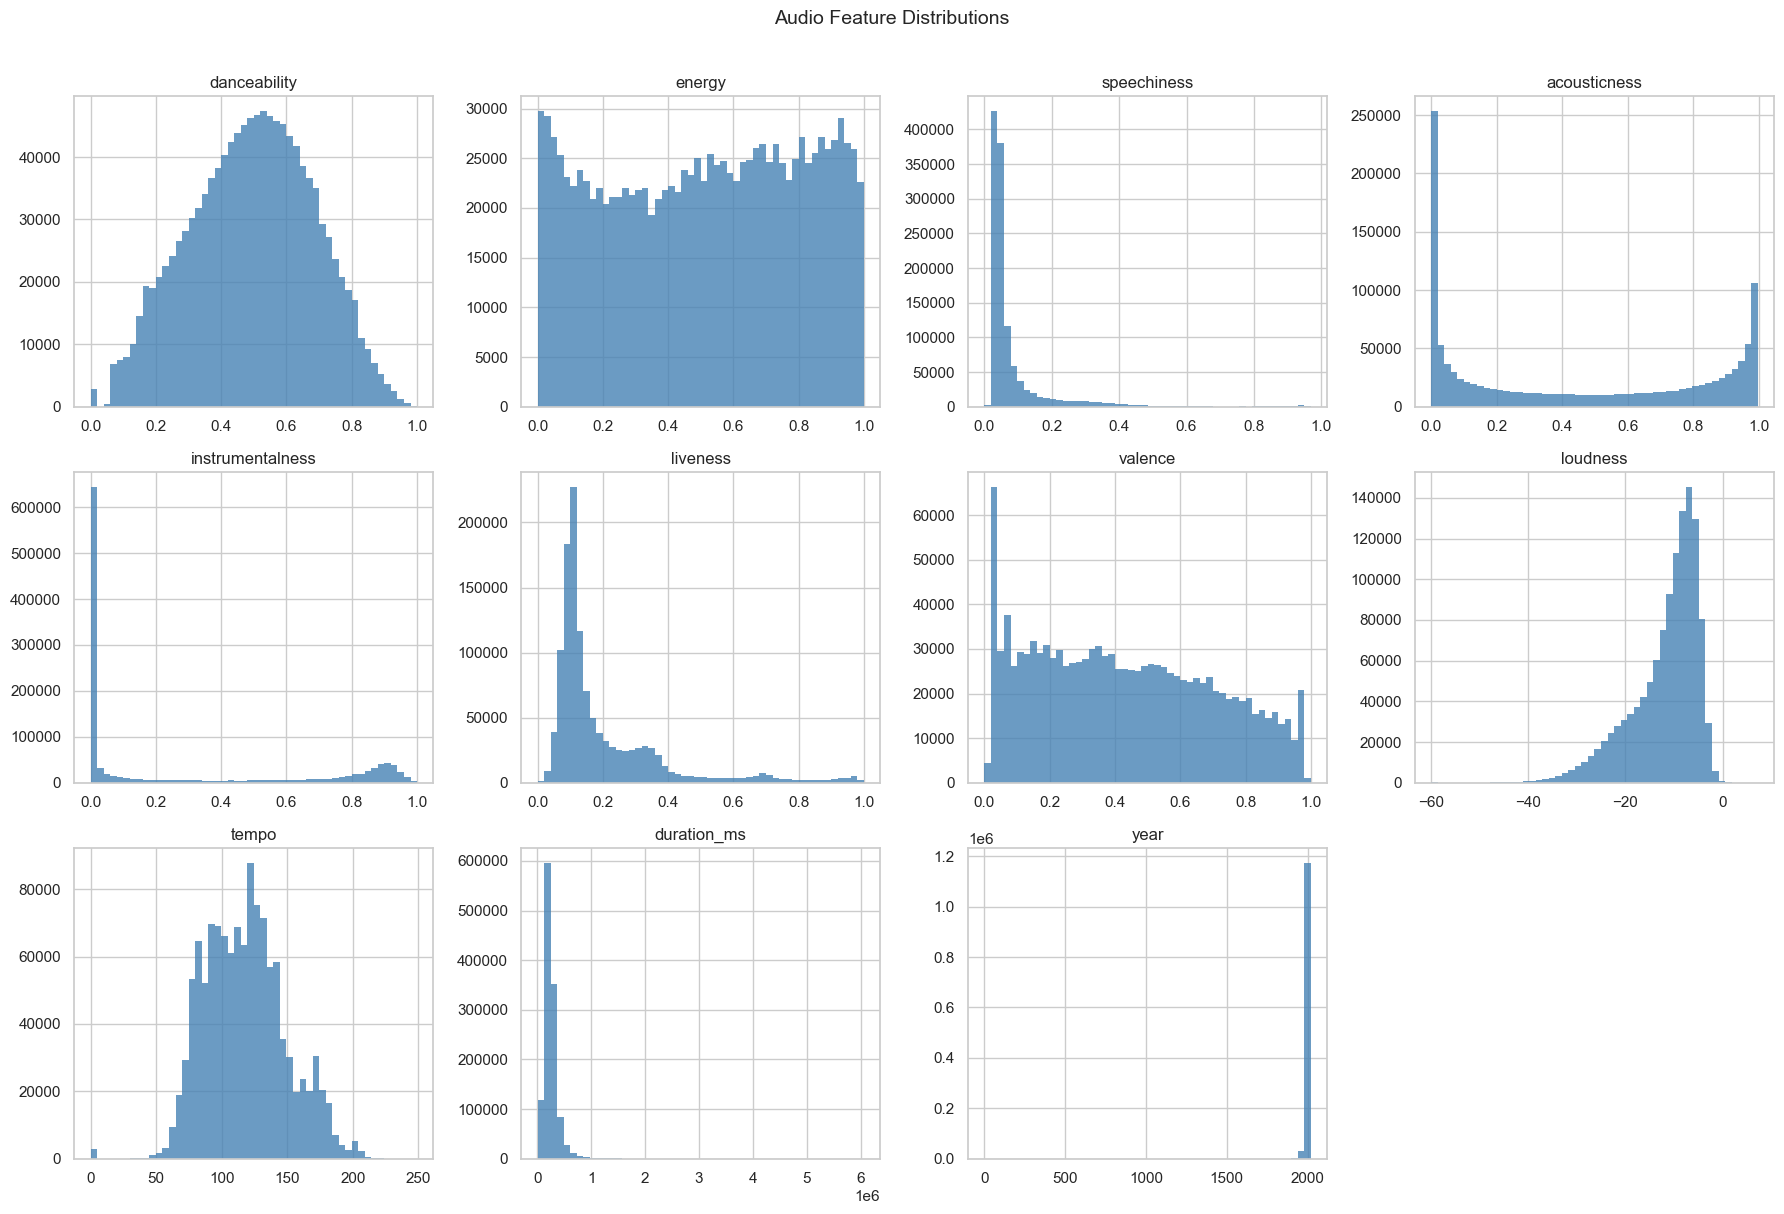

In [10]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

PLOT_FEATURES = ZERO_ONE_FEATURES + ['loudness', 'tempo', 'duration_ms', 'year']

for i, col in enumerate(PLOT_FEATURES):
    axes[i].hist(df[col].dropna(), bins=50, edgecolor='none', color='steelblue', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel('')

# hide unused subplots
for j in range(len(PLOT_FEATURES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Audio Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 7. Categorical Sanity Checks

In [11]:
# key distribution
print("Key distribution:")
print(df['key'].value_counts().sort_index())

print("\nMode distribution (0=minor, 1=major):")
print(df['mode'].value_counts())

print("\nTime signature distribution:")
print(df['time_signature'].value_counts().sort_index())

print("\nExplicit distribution:")
print(df['explicit'].value_counts())

Key distribution:
key
0     149568
1      96357
2     144583
3      39777
4      97612
5     100006
6      63502
7     155382
8      65348
9     133270
10     77164
11     81456
Name: count, dtype: int64

Mode distribution (0=minor, 1=major):
mode
1    808454
0    395571
Name: count, dtype: int64

Time signature distribution:
time_signature
0.0      2809
1.0     19431
3.0    162645
4.0    988647
5.0     30493
Name: count, dtype: int64

Explicit distribution:
explicit
False    1121377
True       82648
Name: count, dtype: int64


## 8. Year / release_date Consistency

In [12]:
# Parse release_date year and compare against year column
df['release_year_parsed'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

mismatch = df[df['year'] != df['release_year_parsed']]
print(f"Year vs parsed release_date mismatches: {len(mismatch)}")
if len(mismatch) > 0:
    display(mismatch[['name', 'artists', 'year', 'release_date', 'release_year_parsed']].head(10))

print(f"\nYear range: {df['year'].min()} – {df['year'].max()}")
print(f"Tracks with year > 2025: {(df['year'] > 2025).sum()}")

Year vs parsed release_date mismatches: 131186


,name,artists,year,release_date,release_year_parsed
169,Above Me,['Rufio'],2001,2001,NaN
170,Still,['Rufio'],2001,2001,NaN
171,One Slowdance,['Rufio'],2001,2001,NaN
172,In My Eyes,['Rufio'],2001,2001,NaN
173,She Cries,['Rufio'],2001,2001,NaN
174,Dipshit,['Rufio'],2001,2001,NaN
175,Just A Memory,['Rufio'],2001,2001,NaN
176,Face The Truth,['Rufio'],2001,2001,NaN
177,Raining in September,['Rufio'],2001,2001,NaN
178,Road to Recovery,['Rufio'],2001,2001,NaN



Year range: 0 – 2020
Tracks with year > 2025: 0


## 9. Correlation Heatmap (Audio Features)

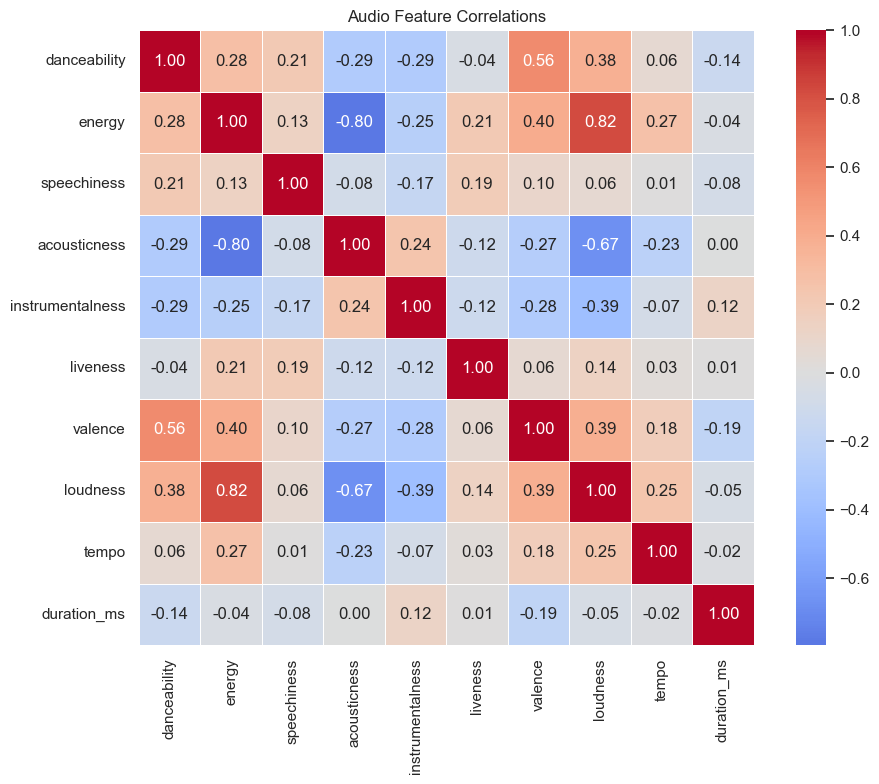

In [13]:
corr = df[AUDIO_FEATURES].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Audio Feature Correlations')
plt.tight_layout()
plt.show()

## 10. Cleaning — Apply & Export

In [14]:
print(f"Before cleaning: {len(df):,} rows")

df_clean = df.copy()

# Drop rows with any null in core columns
core_cols = ['id', 'name', 'artists'] + AUDIO_FEATURES
before = len(df_clean)
df_clean = df_clean.dropna(subset=core_cols)
print(f"Dropped {before - len(df_clean)} rows with nulls in core columns")

# Drop tempo == 0
before = len(df_clean)
df_clean = df_clean[df_clean['tempo'] != 0.0]
print(f"Dropped {before - len(df_clean)} rows with tempo == 0")

# Drop full duplicate rows
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Dropped {before - len(df_clean)} full duplicate rows")

# Drop duplicate track IDs (keep first)
before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset='id', keep='first')
print(f"Dropped {before - len(df_clean)} duplicate track IDs")

# Drop helper column
df_clean = df_clean.drop(columns=['release_year_parsed'], errors='ignore')

print(f"\nAfter cleaning: {len(df_clean):,} rows")
print(f"Removed: {len(df) - len(df_clean):,} rows total")

Before cleaning: 1,204,025 rows
Dropped 3 rows with nulls in core columns
Dropped 2777 rows with tempo == 0
Dropped 0 full duplicate rows
Dropped 0 duplicate track IDs

After cleaning: 1,201,245 rows
Removed: 2,780 rows total


In [15]:
# Final null check on clean df
assert df_clean[core_cols].isnull().sum().sum() == 0, "Still has nulls!"
assert (df_clean['tempo'] == 0).sum() == 0, "Still has zero tempos!"
print("All assertions passed — data is clean.")
df_clean[AUDIO_FEATURES].describe().T.round(3)

All assertions passed — data is clean.


,count,mean,std,min,25%,50%,75%,max
danceability,1201245.0,0.494,0.188,0.000,0.357,0.501,0.633,1.000
energy,1201245.0,0.510,0.294,0.000,0.253,0.524,0.767,1.000
speechiness,1201245.0,0.085,0.116,0.000,0.035,0.045,0.072,0.969
acousticness,1201245.0,0.447,0.385,0.000,0.038,0.388,0.861,0.996
instrumentalness,1201245.0,0.283,0.376,0.000,0.000,0.008,0.718,1.000
liveness,1201245.0,0.202,0.180,0.000,0.097,0.125,0.245,1.000
valence,1201245.0,0.429,0.270,0.000,0.193,0.404,0.645,1.000
loudness,1201245.0,-11.785,6.935,-58.925,-15.223,-9.779,-6.713,7.234
tempo,1201245.0,117.906,30.451,30.018,94.222,116.872,137.108,248.934
duration_ms,1201245.0,249312.681,161909.572,15000.000,174497.000,224537.000,286000.000,6061090.000


In [ ]:
OUT_PATH = r"C:\Users\ryanm\Documents\coding_projects\restaurant_recommendation\data\processed\tracks_features_clean.csv"
df_clean.to_csv(OUT_PATH, index=False)
print(f"Saved clean data to: {OUT_PATH}")